In [ ]:

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-02-17 11:27:06.507688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771327626.697705      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771327626.748181      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771327627.172071      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771327627.172112      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771327627.172115      55 computation_placer.cc:177] computation placer alr

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Exploratory Data Analysis (EDA)

Let's examine the folder structure and count images per class.

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set class distribution:
glioma: 3018 images
meningioma: 2183 images
notumor: 1945 images
pituitary: 2504 images


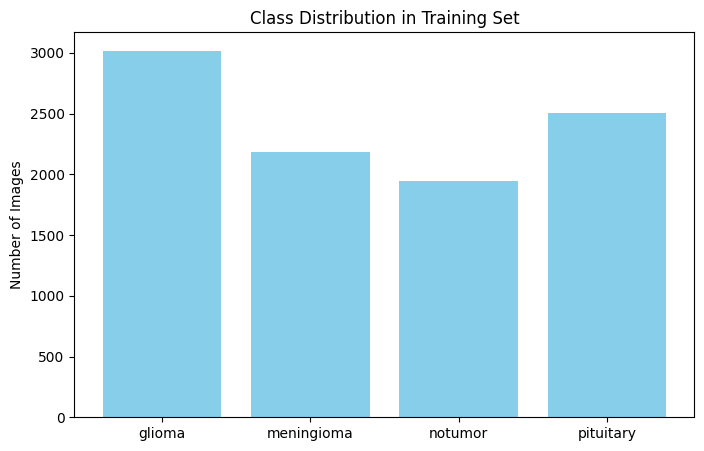

In [2]:
# Define paths
train_dir = '/kaggle/input/datasets/rahulrathod7/brain-tumor-1/Epic and CSCR hospital Dataset/Train'
test_dir = '/kaggle/input/datasets/rahulrathod7/brain-tumor-1/Epic and CSCR hospital Dataset/Test'

class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

# Count images in training set
train_counts = {}
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    train_counts[cls] = len(os.listdir(cls_path))

print("\nTraining set class distribution:")
for cls, count in train_counts.items():
    print(f"{cls}: {count} images")

# Plot distribution
plt.figure(figsize=(8,5))
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of Images')
plt.show()

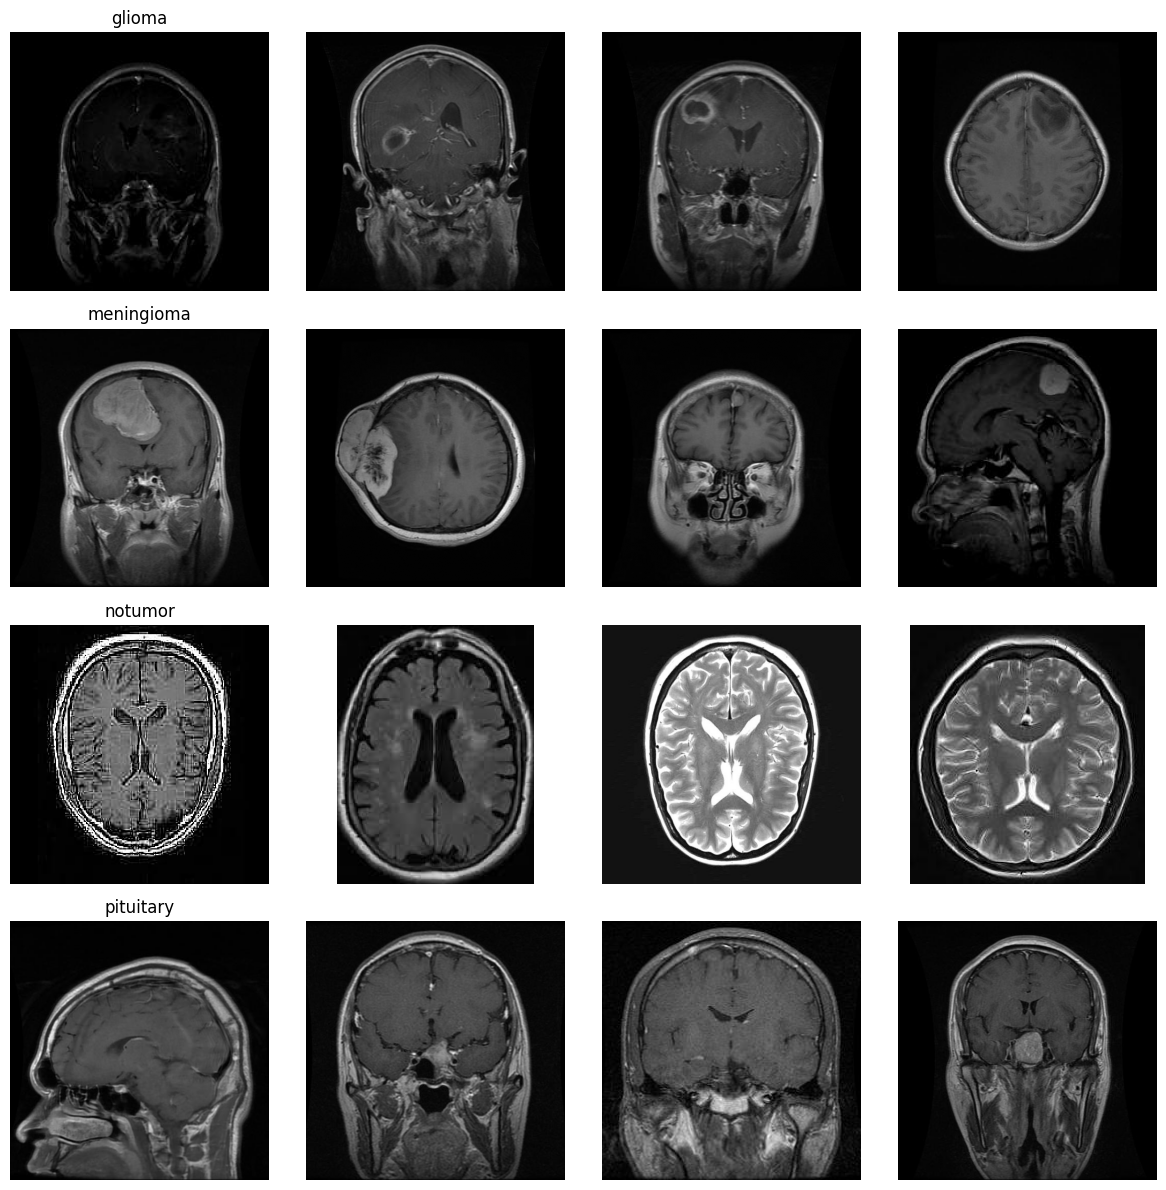

In [3]:
# Display a few sample images from each class
fig, axes = plt.subplots(4, 4, figsize=(12,12))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    img_files = os.listdir(cls_path)[:4]   # first 4 images
    for j, img_file in enumerate(img_files):
        img_path = os.path.join(cls_path, img_file)
        img = plt.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, fontsize=12)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Augmentation

We'll use `ImageDataGenerator` to:
- Rescale pixel values to [0,1] (since VGG16's `preprocess_input` will later zero‑center them).
- Apply augmentation only to training data.
- Split training data into training/validation (80/20) using `validation_split`.

We set the target size to 224×224 as required by VGG16.

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2          # use 20% for validation
)

# Validation and test generators (only rescaling)
valid_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Store class indices mapping
class_indices = train_generator.class_indices
print("\nClass to index mapping:", class_indices)

Found 7722 images belonging to 4 classes.
Found 1928 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.

Class to index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 5. Model Building with VGG16 Transfer Learning

We load the VGG16 base without the top classification layer. We then add:
- GlobalAveragePooling2D
- Dense(256, ReLU)
- Dropout(0.5)
- Dense(4, softmax)

The base is frozen initially.

In [5]:
# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze all layers in the base model
base_model.trainable = False

# Build the model
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)   # important to set training=False for batch norm layers
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.summary()

I0000 00:00:1771327673.802047      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 6. Compute Class Weights to Handle Imbalance

We calculate class weights inversely proportional to class frequencies. These weights will be passed to the `fit` method so that the model pays more attention to minority classes (especially "No Tumor").

In [6]:
# Get class labels from generator
class_labels = list(train_generator.class_indices.keys())
# Count samples per class from the whole training set (including both subsets)
train_labels = train_generator.labels   # labels for all samples in the training folder (after split, but we need total counts)
# Actually, train_generator.labels gives labels for the subset, which is not the full set.
# We'll compute from directory counts.

# Use the earlier train_counts dictionary (contains total counts per class)
total_samples_per_class = [train_counts[cls] for cls in class_labels]

# Compute class weights using sklearn
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(list(class_indices.values())),
    y=np.hstack([[i]*total_samples_per_class[i] for i in range(len(class_labels))])  # synthetic array
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7993704440026508), 1: np.float64(1.1051305542830967), 2: np.float64(1.2403598971722365), 3: np.float64(0.9634584664536742)}


## 7. Phase 1 Training – Classifier Only

We train only the newly added layers while keeping VGG16 frozen. We use callbacks for early stopping, model checkpoint, and learning rate reduction.

In [ ]:
# Compile the model 
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True, mode='max')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

callbacks = [checkpoint, early_stop, reduce_lr]

# Train
history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1771327693.417082     146 service.cc:152] XLA service 0x7f71d800d6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771327693.417122     146 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771327693.938586     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/242 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.1953 - loss: 1.8081 

I0000 00:00:1771327702.283135     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


242/242 ━━━━━━━━━━━━━━━━━━━━ 155s 599ms/step - accuracy: 0.2863 - loss: 1.4798 - val_accuracy: 0.6151 - val_loss: 1.1896 - learning_rate: 1.0000e-04
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 118s 487ms/step - accuracy: 0.4891 - loss: 1.1856 - val_accuracy: 0.6551 - val_loss: 1.0674 - learning_rate: 1.0000e-04
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 118s 487ms/step - accuracy: 0.5956 - loss: 1.0503 - val_accuracy: 0.6561 - val_loss: 0.9898 - learning_rate: 1.0000e-04
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 118s 487ms/step - accuracy: 0.6442 - loss: 0.9486 - val_accuracy: 0.6857 - val_loss: 0.9293 - learning_rate: 1.0000e-04
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 117s 484ms/step - accuracy: 0.6772 - loss: 0.8860 - val_accuracy: 0.6909 - val_loss: 0.8808 - learning_rate: 1.0000e-04
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 116s 478ms/step - accuracy: 0.7032 - loss: 0.8230 - val_accuracy: 0.7012 - val_loss: 0.8658 - learning_rate: 1.0000e-04
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 115s 477ms/

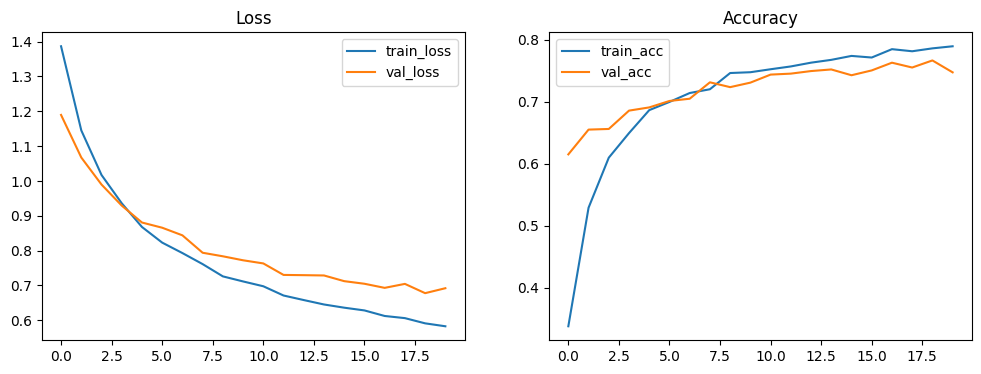

In [8]:
# Plot training history
def plot_history(history):
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train_acc')
    axes[1].plot(history.history['val_accuracy'], label='val_acc')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    plt.show()

plot_history(history_phase1)

## 8. Phase 2 – Fine‑tuning with Class Weights

Now we unfreeze the last 30 layers of VGG16 (you can adjust this number) and continue training with a very low learning rate.

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 155s 546ms/step - accuracy: 0.8029 - loss: 0.5393 - val_accuracy: 0.8019 - val_loss: 0.5488 - learning_rate: 1.0000e-05
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 124s 513ms/step - accuracy: 0.8910 - loss: 0.3010 - val_accuracy: 0.8854 - val_loss: 0.3024 - learning_rate: 1.0000e-05
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 122s 506ms/step - accuracy: 0.9357 - loss: 0.1994 - val_accuracy: 0.8838 - val_loss: 0.3470 - learning_rate: 1.0000e-05
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 124s 513ms/step - accuracy: 0.9434 - loss: 0.1567 - val_accuracy: 0.9144 - val_loss: 0.2486 - learning_rate: 1.0000e-05
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 122s 506ms/step - accuracy: 0.9568 - loss: 0.1237 - val_accuracy: 0.9191 - val_loss: 0.2220 - learning_rate: 1.0000e-05
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 121s 499ms/step - accuracy: 0.9626 - loss: 0.1062 - val_accuracy: 0.9372 - val_loss: 0.1749 - learning_rate: 1.0000e-05
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 

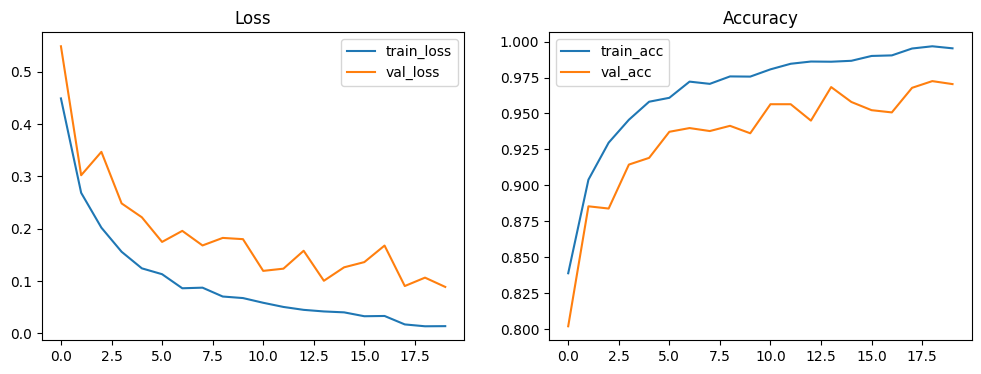

In [9]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re‑compile with a lower learning rate
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ModelCheckpoint for phase2
checkpoint_phase2 = ModelCheckpoint('best_model_phase2.keras', monitor='val_accuracy', save_best_only=True, mode='max')
early_stop_phase2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_phase2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

callbacks_phase2 = [checkpoint_phase2, early_stop_phase2, reduce_lr_phase2]

# Continue training
history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,
    verbose=1
)

plot_history(history_phase2)

## 9. Evaluation on Test Set

We load the best model from phase2 (or use the current one if it already is the best) and evaluate on the unseen test set. We compute:
- Classification report (precision, recall, F1)
- Confusion matrix
- AUC‑ROC for each class (one‑vs‑rest)

76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 233ms/step - accuracy: 0.9754 - loss: 0.1242
Test Accuracy: 0.9772
Test Loss: 0.1083
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.96      0.97       755
  meningioma       0.98      0.95      0.96       546
     notumor       0.98      1.00      0.99       487
   pituitary       0.98      1.00      0.99       626

    accuracy                           0.98      2414
   macro avg       0.98      0.98      0.98      2414
weighted avg       0.98      0.98      0.98      2414



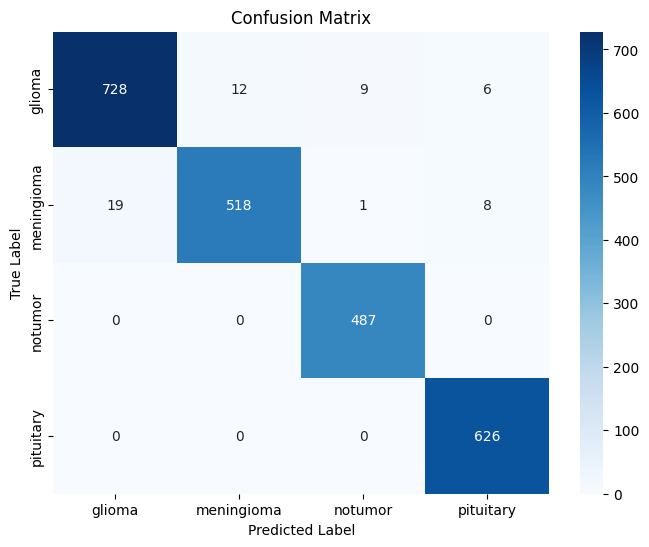

AUC for glioma: 0.9942
AUC for meningioma: 0.9979
AUC for notumor: 0.9988
AUC for pituitary: 1.0000


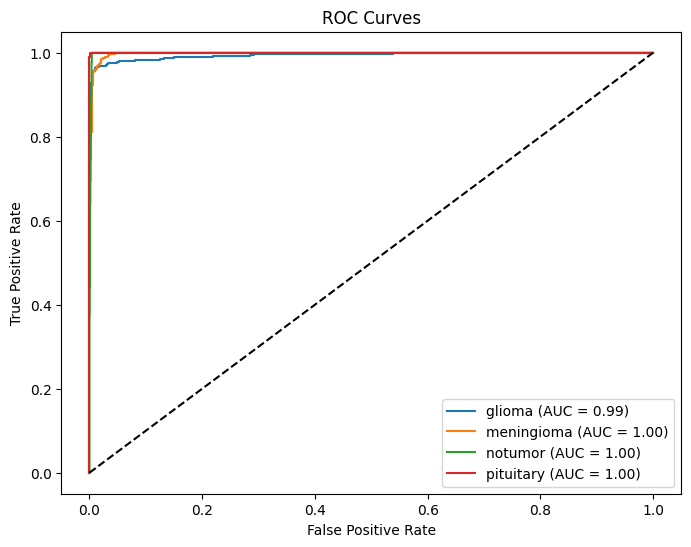

In [10]:
# Load best model (if saved)
# model = keras.models.load_model('best_model_phase2.keras')

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions and true labels
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# AUC-ROC (one-vs-rest)
# Binarize the true labels for each class
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
auc_scores = []
for i in range(4):
    auc = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
    auc_scores.append(auc)
    print(f"AUC for {class_labels[i]}: {auc:.4f}")

# Plot ROC curves (optional)
plt.figure(figsize=(8,6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {auc_scores[i]:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

## 10. Single Image Prediction Function

We define a function to predict the class of a single MRI image. It loads the image, preprocesses it (resize, rescale, apply VGG16 preprocessing), and returns the predicted class and confidence.

In [11]:
def predict_image(img_path, model, class_names, img_size=224):
    """
    Predict class for a single image.
    """
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.vgg16 import preprocess_input

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)   # VGG16 specific preprocessing

    # Predict
    preds = model.predict(img_array, verbose=0)[0]
    pred_class = np.argmax(preds)
    confidence = preds[pred_class]

    return class_names[pred_class], confidence, preds

# Example usage:
# cls, conf, probs = predict_image('path_to_image.jpg', model, class_labels)
# print(f"Predicted: {cls} with confidence {conf:.2f}")

## 11. Save the Final Model

We save the model in the native Keras format (`.keras`). This file can later be loaded and deployed (e.g., in a Streamlit app).

In [12]:
# Save the model
model.save('brain_tumor_vgg16.keras')
print("Model saved as 'brain_tumor_vgg16.keras'")

# Optionally, also save in HDF5 format for compatibility
model.save('brain_tumor_vgg16.h5')
print("Model also saved as 'brain_tumor_vgg16.h5'")

Model saved as 'brain_tumor_vgg16.keras'
Model also saved as 'brain_tumor_vgg16.h5'
